# BandagedPocketCube

Edit `bandage`, `preference`, `diagram_mode`, and `face_colors` before running the cell using the **v2/.venv** kernel, with GAP on `PATH`.

Counts use the fixed face frame and include solved; unmarked center spin is excluded.
The human method starts at the reference bandage shape. Face colors affect diagrams only.

Choose a `c.DiagramMode` enum member. Face colors accept names such as `"blue"`, `"orange"`, and `"gray"`, as well as hex colors.

The guide selects reusable templates and shared pieces, including legal symmetry regrips. Set `preference` to `"memory"`, `"execution"`, or `"recognition"` to compare the tradeoffs.


| Shapes | Isotropy group size | Total scrambles |
| ---: | ---: | ---: |
| 580 | 432 | 250,560 |

# Solution from solved shape

This computational method covers all **432 reachable colored states** whose bandage shape is already the declared reference shape.

In each stage's diagrams: face centers are colored to inform you how to orient the cube before algorithm application. Blocks already solved are dark grey. The block this stage requires you to identify is colored. Striped white color indicates a white sticker, plain white indicates unsolved sticker of any color.

## Algorithms

Singmaster notation uses U/R/F/D/L/B, an apostrophe for an inverse turn, 2 for a half turn, x/y/z represent whole cube rotations 90° in the direction of an R/U/F move respectively.

| Turn sequence | Block action | Structure |
| --- | --- | --- |
| `M2: F R' D' F' R U F' L' U' F U F' L F U'` | `([UBR-UR] [UFL-UF] [FR-DFR])(UFR+ DBL-)(DB DL)` | `F (D' F')^R [U', F]^(L F U')` |
| `M3: U F' L' F U2 R B2 R' U2 F' L F U'` | `([UBR-UR] [UFL-UF])(UFR DBL)(DB+ DL+)` | `B2^(R' U2 L^F U')` |

### Shared piece recipes

| Piece | Turn sequence |
| --- | --- |
| `C1` | `U F' L'` |

| Algorithm | Recipe |
| --- | --- |
| `M2` | `x y (C1) y' x' F' R C1 U' F U F' C1^-1` |
| `M3` | `(C1 F U2 R) (B2) (C1 F U2 R)^-1` |

## Stage 1: Place Edge DL

This stage has 3 exact cases and 2 instruction families. It reduces the remaining possibilities from 432 to 144.

Check the target's position only; its sticker orientation does not change the case.

### Case 1

Execute `M3: U F' L' F U2 R B2 R' U2 F' L F U'`.

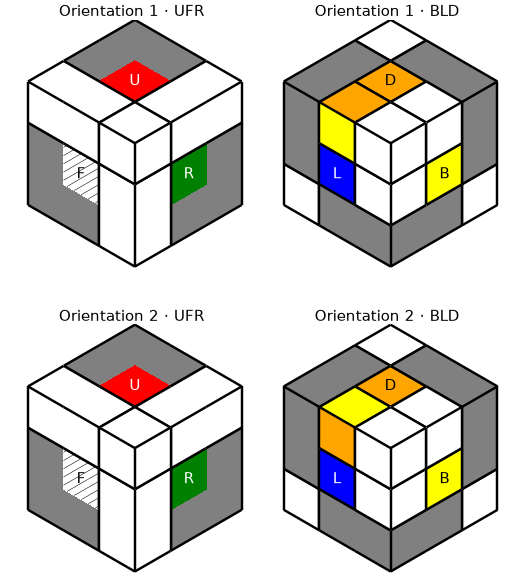

### Case 2

Execute `M3: U F' L' F U2 R B2 R' U2 F' L F U'`.

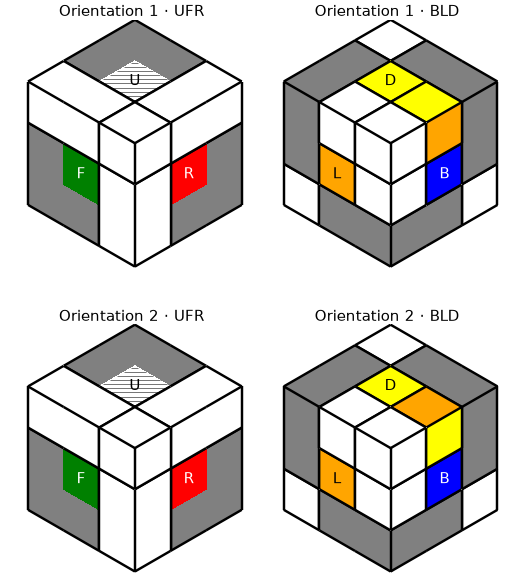

### Case 3

Skip — already placed

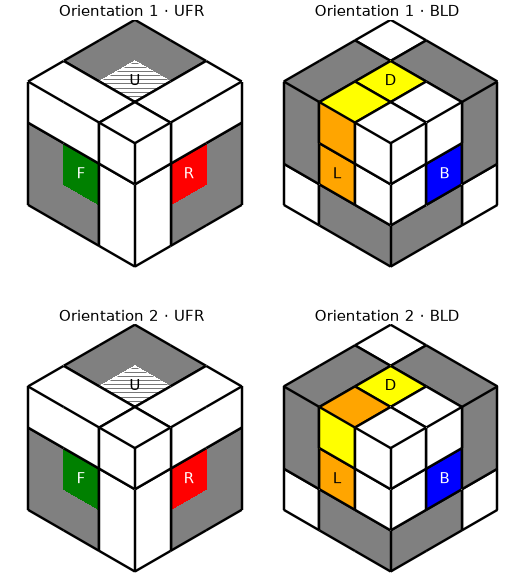

## Stage 2: Orient Edge DL

This stage has 2 exact cases and 1 instruction family. It reduces the remaining possibilities from 144 to 72.

### Case 1

Skip — already correct

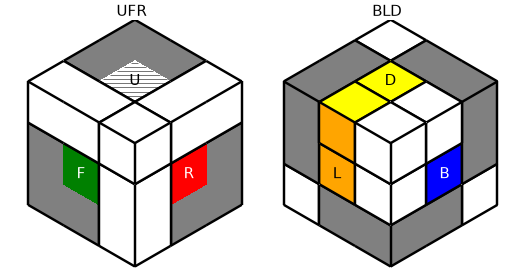

### Case 2

Execute `M2 M3: F R' D' F' R U F' L' U' F U' R B2 R' U2 F' L F U'`.

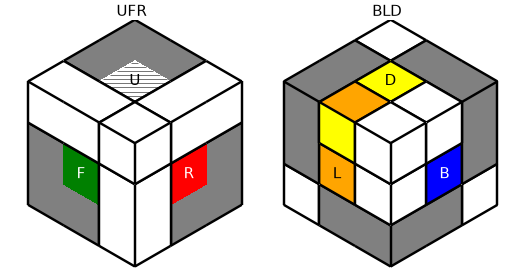

## Stage 3: Solve Pair UBR-UR

This stage has 3 exact cases and 1 instruction family. It reduces the remaining possibilities from 72 to 24.

### Case 1

Skip — already correct

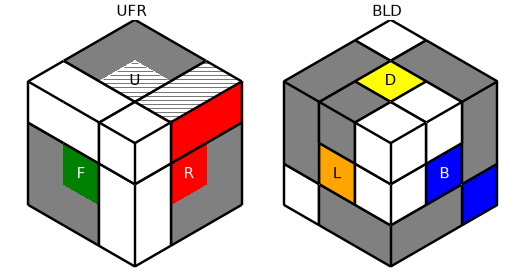

### Case 2

Execute `M2^-1: U F' L' F U' F' U L F U' R' F D R F'`.

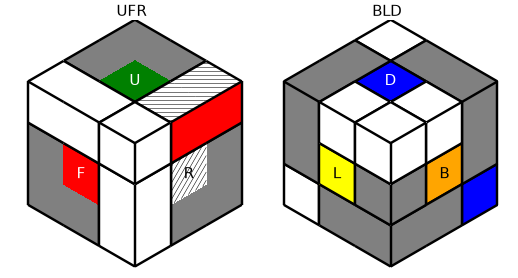

### Case 3

Execute `M2: F R' D' F' R U F' L' U' F U F' L F U'`.

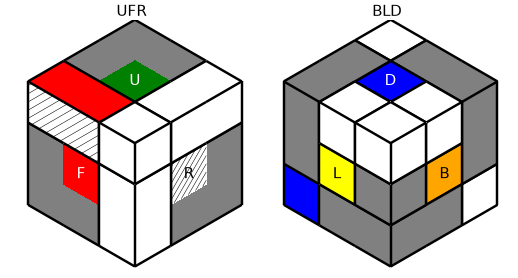

Also correct automatically after this stage: place Pair UBR-UR.

## Stage 4: Solve Pair UFL-UF

This stage has 2 exact cases and 1 instruction family. It reduces the remaining possibilities from 24 to 12.

### Case 1

Skip — already correct

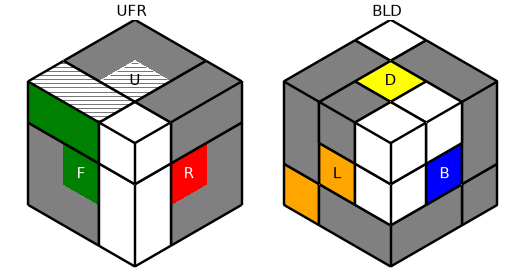

### Case 2

Execute `M3: U F' L' F U2 R B2 R' U2 F' L F U'`.

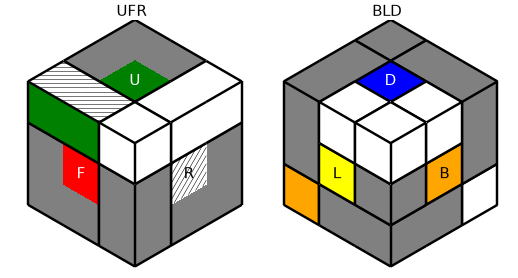

Also correct automatically after this stage: place Pair UFL-UF; place Pair FR-DFR; fully solve Pair FR-DFR.

## Stage 5: Solve Edge BL

This stage has 4 exact cases and 3 instruction families. It reduces the remaining possibilities from 12 to 3.

### Case 1

Skip — already correct

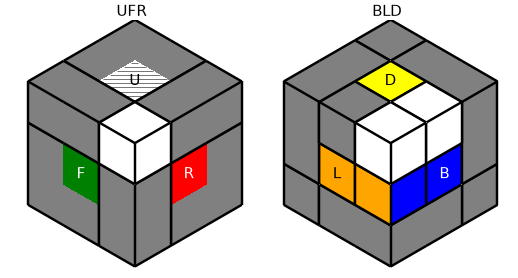

### Case 2

Execute `(x' z' (M2) z x)^-1 M3 x' z' (M2) z x x y (M3) y' x': R U' B' U R' U' R B U R' F' U F U2 R B2 R' U2 F' U' F R U' B' R' U R U' B U R' F R' D' R F2 U L2 U' F2 R' D R F'`.

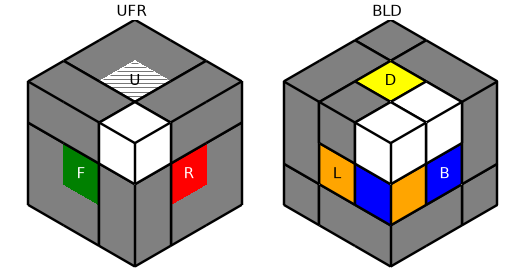

### Case 3

Execute `(x' z' (M2) z x)^-1 M2^-1 (x' z' (M2) z x)^-1: R U' B' U R' U' R B U R' F' U F U' F' U L F U' R' F D R F' R U' B' U R' U' R B U R' F' U L F U'`.

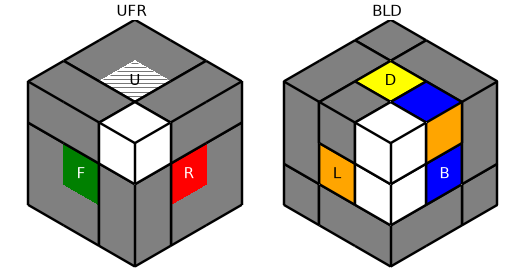

### Case 4

Execute `(x y (M2) y' x')^-1 (x' z' (M2) z x)^-2: F R' D' R F' R' F D R F' U' R U R' U' R B U R' F' U L F U' R U' B' U R' U' R B U R' F' U L F U'`.

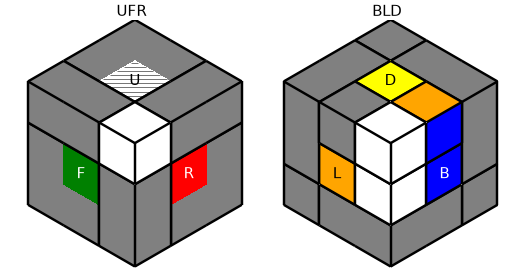

Also correct automatically after this stage: place Corner UFR; place Edge BL; place Corner DBL; place Edge DB; fully solve Edge DB.

## Stage 6: Orient Corner UFR

This stage has 3 exact cases and 2 instruction families. It reduces the remaining possibilities from 3 to 1.

### Case 1

Skip — already correct

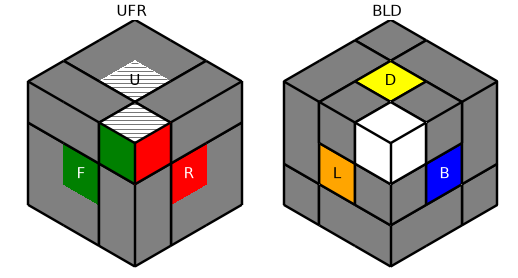

### Case 2

Execute `M2 M3 M2 M3: F R' D' F' R U F' L' U' F U' R B2 R' U2 F' L F U' F R' D' F' R U F' L' U' F U' R B2 R' U2 F' L F U'`.

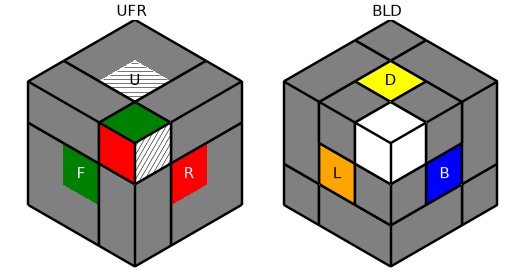

### Case 3

Execute `M3 M2^-1 M3 M2^-1: U F' L' F U2 R B2 R' U F' U L F U' R' F D R F' U F' L' F U2 R B2 R' U F' U L F U' R' F D R F'`.

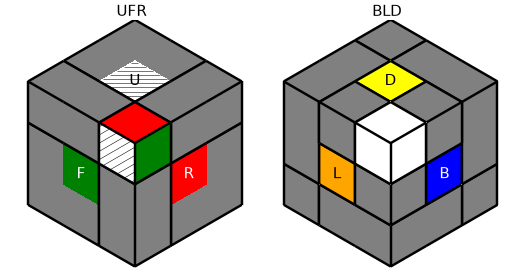

Also correct automatically after this stage: fully solve Corner DBL.

After the final stage every modeled corner and edge sticker is solved. Unmarked center spin and independent virtual-core spin are outside this model.


In [1]:
import bce_v2 as c
from bce_v2.notebook import refresh_renderers
from IPython.display import Markdown, display

refresh_renderers()

bandage = [
    1, 1, 2,
    1, 1, 2,
    3, 3, 0,

    0, 0, 4,
    0, 0, 4,
    5, 5, 6,

    0, 0, 4,
    0, 0, 4,
    5, 5, 6,
]

preference = "memory"
diagram_mode = c.DiagramMode.OPPOSITE_CORNERS
face_colors = {
    'U': 'white', 'R': 'red', 'F': 'green',
    'D': 'yellow', 'L': 'orange', 'B': 'blue',
}

analysis = c.analyze_isotropy(bandage)
display(Markdown(
    "| Shapes | Isotropy group size | Total scrambles |\n"
    "| ---: | ---: | ---: |\n"
    f"| {analysis.loops.shape_count:,} | {analysis.group_order:,} | {analysis.colored_state_count:,} |"
))

repertoire = c.template_human_repertoire(analysis, preference=preference)
display(Markdown(repertoire.write_guide(diagram_mode=diagram_mode, face_colors=face_colors)))
